# Rotulagem por similaridade

### Extração de clusters

In [ ]:
import pandas as pd
import random
import numpy as np
import hdbscan
from umap import UMAP
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
from hyperopt import hp
from hyperopt import fmin, tpe, STATUS_OK, space_eval, Trials
from functools import partial

In [ ]:
docs = pd.read_csv('../data/processed/trump_marcelo_processed.csv')

In [ ]:
from sentence_transformers import SentenceTransformer

#mpnet_model = SentenceTransformer("all-mpnet-base-v2", device="cuda")
minilm_model = SentenceTransformer("all-MiniLM-L6-v2", device="cuda")
#bert_base_model = SentenceTransformer("xlm-r-bert-base-nli-stsb-mean-tokens", device="cuda")

#mpnet_embeddings = mpnet_model.encode(docs.text, show_progress_bar=True)
minilm_embeddings = minilm_model.encode(docs.text, show_progress_bar=True)
#bert_base_embeddings = bert_base_model.encode(docs.text, show_progress_bar=True)

In [ ]:
def generate_clusters(embeddings,
                      n_neighbors,
                      n_components, 
                      min_cluster_size,
                      random_state = None):
    """
    Generate HDBSCAN cluster object after reducing embedding dimensionality with UMAP
    """
    
    umap_embeddings = (UMAP(n_neighbors=n_neighbors, 
                                n_components=n_components, 
                                metric='cosine', 
                                random_state=random_state)
                                .fit_transform(embeddings))

    clusters = hdbscan.HDBSCAN(min_cluster_size = min_cluster_size,
                               metric='euclidean', 
                               cluster_selection_method='eom').fit(umap_embeddings)

                               

    return clusters

In [ ]:
import numpy as np

def score_clusters(clusters, prob_threshold = 0.05):
    """
    Returns the label count and cost of a given cluster supplied from running hdbscan
    """
    
    cluster_labels = clusters.labels_
    label_count = len(np.unique(cluster_labels))
    total_num = len(clusters.labels_)
    cost = (np.count_nonzero(clusters.probabilities_ < prob_threshold)/total_num)
    
    return label_count, cost

In [ ]:
def objective(params, embeddings, clusters_lower, clusters_upper):
    """
    Objective function for hyperopt to minimize, which incorporates constraints
    on the number of clusters we want to identify
    """
    
    clusters = generate_clusters(embeddings, 
                                 n_neighbors = params['n_neighbors'], 
                                 n_components = params['n_components'], 
                                 min_cluster_size = params['min_cluster_size'],
                                 random_state = params['random_state'])
    
    label_count, cost = score_clusters(clusters, prob_threshold = 0.05)
    
    #15% penalty on the cost function if outside the desired range of groups
    if (label_count < clusters_lower) | (label_count > clusters_upper):
        penalty = 0.15 
    else:
        penalty = 0
    
    loss = cost + penalty
    
    return {'loss': loss, 'label_count': label_count, 'status': STATUS_OK}

In [ ]:
def bayesian_search(embeddings, space, clusters_lower, clusters_upper, max_evals):
    """
    Perform bayseian search on hyperopt hyperparameter space to minimize objective function
    """
    
    trials = Trials()
    fmin_objective = partial(objective, embeddings=embeddings, clusters_lower=clusters_lower, clusters_upper=clusters_upper)
    best = fmin(fmin_objective,  
                space = space, 
                algo=tpe.suggest,
                max_evals=max_evals, 
                trials=trials)

    best_params = space_eval(space, best)
    print ('best:')
    print (best_params)
    print (f"label count: {trials.best_trial['result']['label_count']}")
    
    best_clusters = generate_clusters(embeddings, 
                                      n_neighbors = best_params['n_neighbors'], 
                                      n_components = best_params['n_components'], 
                                      min_cluster_size = best_params['min_cluster_size'],
                                      random_state = best_params['random_state'])
    
    return best_params, best_clusters, trials

In [ ]:
hspace = {
    'n_neighbors': hp.choice('n_neighbors',range(10,20)),
    'n_components': hp.choice('n_components',range(3,10)),
    'min_cluster_size': hp.choice('min_cluster_size',range(10,50)),
    'random_state':42
}

clusters_lower=25
clusters_upper=75
max_evals = 20

In [ ]:
minilm_best_params, minilm_best_clusters, minilm_trials = bayesian_search(minilm_embeddings,
                                                                       space=hspace,
                                                                       clusters_lower=clusters_lower,
                                                                       clusters_upper=clusters_upper,
                                                                       max_evals=max_evals)

In [ ]:
minilm_best_params

### BERTopic

In [1]:
import os

import hdbscan
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer, util
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP

os.environ["TOKENIZERS_PARALLELISM"] = "false"

model = SentenceTransformer("all-MiniLM-L6-v2", device="cuda")


umap_model = UMAP(n_neighbors=11, n_components=8, metric='cosine')


hdbscan_model = hdbscan.HDBSCAN(min_cluster_size = 15,
                                metric='euclidean', 
                                cluster_selection_method='eom')


vectorizer_model = CountVectorizer(ngram_range=(2, 2), stop_words="english")



topic_model = BERTopic(embedding_model=model,
                       top_n_words=10,
                       #nr_topics = 'auto',
                       umap_model=umap_model,
                       hdbscan_model=hdbscan_model,
                       vectorizer_model=vectorizer_model,
                       low_memory=True,
                       calculate_probabilities=False, 
                       verbose=True)

/home/andre/Documentos/Workspace/mestrado/dissertacao/venv/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import pandas as pd

docs = pd.read_csv('../data/processed/trump_marcelo_processed.csv')

topics, probs = topic_model.fit_transform(docs.text)

Batches: 100%|██████████| 1988/1988 [00:09<00:00, 211.98it/s]
2022-12-22 16:57:11,655 - BERTopic - Transformed documents to Embeddings
2022-12-22 16:57:56,735 - BERTopic - Reduced dimensionality
2022-12-22 16:58:00,464 - BERTopic - Clustered reduced embeddings


In [ ]:
topic_model.visualize_topics()

In [3]:
topic_docs = {topic: [] for topic in set(topics)}
for topic, doc in zip(topics, docs.text):
    topic_docs[topic].append(doc)

### Buscar os clusters correspondentes a cada linha do query set e atribuir-los a label correspondente

- Desafios
    - O mesmo tópico pode ser atrbuído a rótulos diferentes dependendo da consulta
        - Criar sistema para atribuir ao tópico o rótulo mais frequênte


In [4]:
def find_clusters(query_set):
    clusters_list = list()
    for index in range(len(query_set)):
        finded_clusters = topic_model.find_topics(query_set.text[index])
        proba_index = 0
        for cluster_number in finded_clusters[0]:
            if cluster_number != -1:
                assigned_clusters = {
                    "number": cluster_number,
                    "label" : query_set.target[index],
                    "proba" : finded_clusters[1][proba_index]
                }
                clusters_list.append(assigned_clusters)
                proba_index += 1
           

    return pd.DataFrame(clusters_list)

In [5]:
import numpy as np

def assingn_most_representative_label_by_proba(pre_labeled_clusters, threshold):
    clusters_list = list()
    for cluster_number in pre_labeled_clusters.number.unique():
        grouped_topics = pre_labeled_clusters[pre_labeled_clusters.number == cluster_number].groupby(['number','proba','label']).proba.max()
        max_proba = grouped_topics.values.max()
        if max_proba >= threshold:
            most_frequent_label = {
                'number': cluster_number,
                'label' : grouped_topics.index[np.argmax(grouped_topics)][2]  
            }
            clusters_list.append(most_frequent_label)
    return pd.DataFrame(clusters_list)

In [6]:
import numpy as np

def assingn_most_representative_label_by_frequency(pre_labeled_clusters):
    clusters_list = list()
    for cluster_number in pre_labeled_clusters.number.unique():
        grouped_topics = pre_labeled_clusters[pre_labeled_clusters.number == cluster_number].groupby(['number','label']).label.count()
        most_frequent_label = {
            'number': cluster_number,
            'label' : grouped_topics.index[np.argmax(grouped_topics)][1]  
        }
        clusters_list.append(most_frequent_label)
    return pd.DataFrame(clusters_list)

### Rotular  os documentos presentes nos clusters com as labels correspondente

In [7]:
def dataset_labeling(labeled_clusters):
    docs_list = list()
    for cluster_number in labeled_clusters.number:
       for docs in topic_docs[cluster_number]:
                    docs ={
                        "text": docs,
                        "label": labeled_clusters[labeled_clusters.number == cluster_number].label.values[0]
                    }
                    docs_list.append(docs)

    return pd.DataFrame(docs_list)

### Executando o pipeline

In [8]:
import pandas as pd
import seaborn as sns

query_set = pd.read_csv('../data/validation.csv')

In [9]:
pre_labeled_clusters = find_clusters(query_set)

<AxesSubplot: xlabel='label', ylabel='count'>

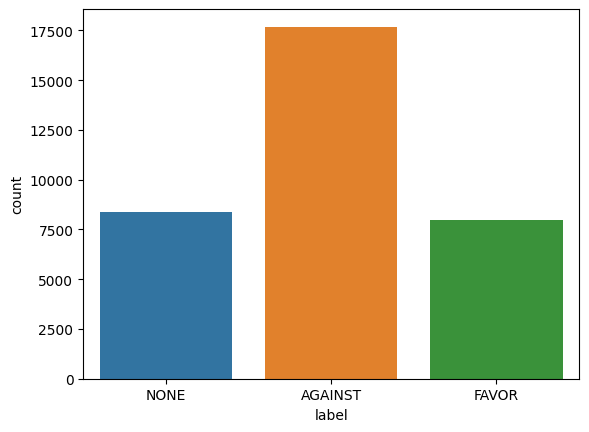

In [16]:
labeled_clusters = assingn_most_representative_label_by_proba(pre_labeled_clusters, 0)
labeled_dataset =  dataset_labeling(labeled_clusters)
labeled_dataset.to_csv('../data/labeled_dataset_marcelo.csv', index=False)
sns.countplot(x=labeled_dataset['label'], label = 'count')

<AxesSubplot: xlabel='label', ylabel='count'>

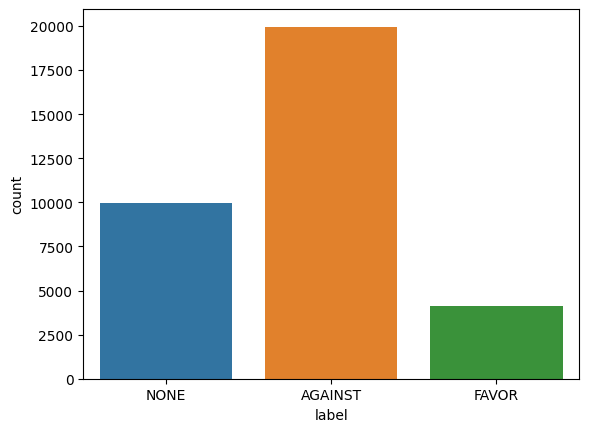

In [17]:
labeled_clusters = assingn_most_representative_label_by_frequency(pre_labeled_clusters)
labeled_dataset =  dataset_labeling(labeled_clusters)
labeled_dataset.to_csv('../data/labeled_dataset_marcelo.csv', index=False)
sns.countplot(x=labeled_dataset['label'], label = 'count')